# ETL — NASA Exoplanet Archive
**Objetivo:** Preparar el dataset para predecir el `discoverymethod` de cada exoplaneta.

Pasos:
1. Carga y filtrado inicial
2. Eliminación de columnas irrelevantes
3. Análisis y tratamiento de nulos
4. Tratamiento del desbalance de clases
5. Exportación del dataset objetivo

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Carga y filtrado inicial

In [8]:
df_raw = pd.read_csv('../Data/NASA_Exoplanet_Archive_Data.csv')
print(f'Filas totales: {len(df_raw)}')
print(f'Columnas totales: {df_raw.shape[1]}')

Filas totales: 36418
Columnas totales: 91


In [9]:
# Cada planeta tiene múltiples filas (una por publicación).
# default_flag=1 marca la fila canónica/más actualizada por planeta.
df = df_raw[df_raw['default_flag'] == 1].copy()
df = df.reset_index(drop=True)
print(f'Filas tras filtrar default_flag=1: {len(df)}')
print(f'Planetas únicos: {df["pl_name"].nunique()}')

Filas tras filtrar default_flag=1: 5757
Planetas únicos: 5757


## 2. Eliminación de columnas irrelevantes

Se eliminan:
- **Columnas de error** (`err1`, `err2`): no aportan al modelado predictivo.
- **Columnas de límite** (`lim`): flags técnicos instrumentales.
- **Metadatos y referencias**: `pl_refname`, `st_refname`, `sy_refname`, `rowupdate`, `pl_pubdate`, `releasedate`.
- **Identificadores no analíticos**: `pl_name`, `hostname`, `disc_facility`, `soltype`.
- **Duplicados de unidades**: `pl_radj`, `pl_bmassj` (se conserva en unidades terrestres: `pl_rade`, `pl_bmasse`).
- **Coordenadas en string**: `rastr`, `decstr` (se conserva `ra`, `dec`).
- **`default_flag`**: ya fue usado para filtrar, no aporta varianza.

In [11]:
# Columnas de error
error_cols = [c for c in df.columns if c.endswith('err1') or c.endswith('err2')]

# Columnas de límite
lim_cols = [c for c in df.columns if c.endswith('lim')]

# Metadatos y referencias
meta_cols = ['pl_refname', 'st_refname', 'sy_refname', 'rowupdate',
             'pl_pubdate', 'releasedate', 'soltype', 'pl_bmassprov',
             'st_metratio', 'st_spectype']

# Identificadores
id_cols = ['pl_name', 'hostname', 'disc_facility', 'default_flag', 'ttv_flag']

# Coordenadas string y duplicados de unidades
redundant_cols = ['rastr', 'decstr', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
                  'pl_radjlim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
                  'pl_bmassjlim']

cols_to_drop = list(set(error_cols + lim_cols + meta_cols + id_cols + redundant_cols))

# Filtrar solo las que existen
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

print(f'Columnas a eliminar: {len(cols_to_drop)}')
df = df.drop(columns=cols_to_drop)
print(f'Columnas restantes: {df.shape[1]}')
print(df.columns.tolist())

Columnas a eliminar: 0
Columnas restantes: 22
['sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_orbeccen', 'pl_insol', 'pl_eqt', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_logg', 'ra', 'dec', 'sy_dist', 'sy_vmag', 'sy_kmag', 'sy_gaiamag']


## 3. Análisis y tratamiento de nulos

Estrategia por columna según porcentaje de nulos y relevancia para el target:

| Columna | % Nulos | Estrategia | Justificación |
|---|---|---|---|
| `pl_insol`, `pl_eqt` | >75% | **Drop** | Baja relevancia para método de descubrimiento + demasiados nulos |
| `pl_orbeccen`, `pl_bmasse` | ~53-59% | **Mediana por clase** | Varían significativamente entre métodos de descubrimiento |
| Resto | <40% | **Mediana global** | Porcentaje manejable, variación entre clases baja |

Para `pl_orbeccen` y `pl_bmasse` también se agrega una columna indicadora binaria (`_missing`) que captura si el valor original era nulo, ya que la **ausencia misma es información** (ej: Transit raramente mide masa directamente).

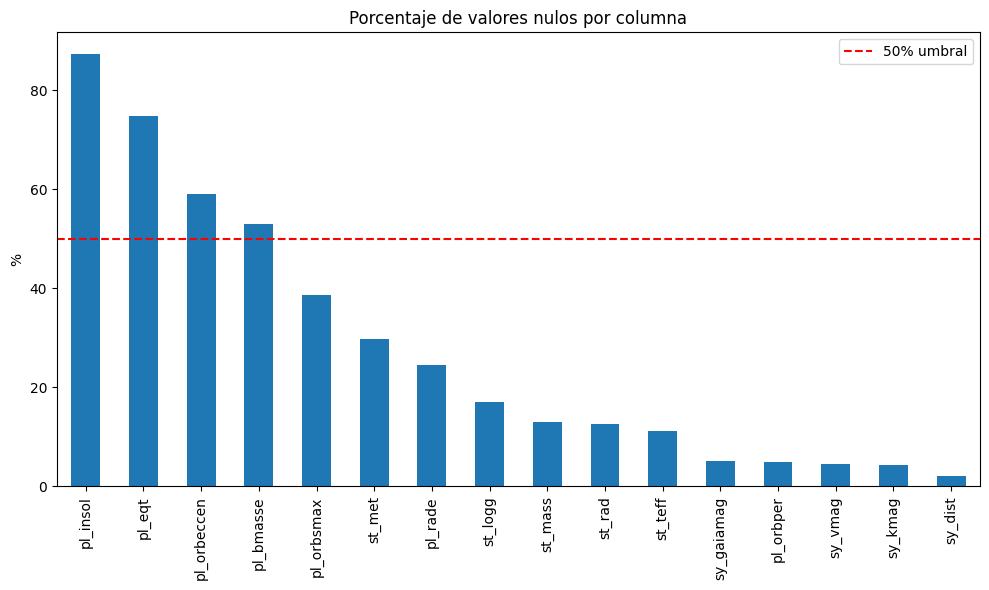

pl_insol      87.3024
pl_eqt        74.7959
pl_orbeccen   59.1106
pl_bmasse     52.9964
pl_orbsmax    38.5618
st_met        29.7030
pl_rade       24.5788
st_logg       17.0922
st_mass       13.0450
st_rad        12.5413
st_teff       11.2211
sy_gaiamag     5.1763
pl_orbper      4.9505
sy_vmag        4.4294
sy_kmag        4.3425
sy_dist        2.1018


In [12]:
# Porcentaje de nulos por columna
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

plt.figure(figsize=(10, 6))
null_pct.plot(kind='bar')
plt.axhline(50, color='red', linestyle='--', label='50% umbral')
plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('%')
plt.legend()
plt.tight_layout()
plt.show()

print(null_pct.to_string())

In [13]:
# Drop: pl_insol y pl_eqt — >75% nulos y baja relevancia para discoverymethod
drop_high_null = [c for c in ['pl_insol', 'pl_eqt'] if c in df.columns]
print(f'Columnas dropeadas por nulos + baja relevancia: {drop_high_null}')
df = df.drop(columns=drop_high_null)
print(f'Columnas restantes: {df.shape[1]}')

Columnas dropeadas por nulos + baja relevancia: ['pl_insol', 'pl_eqt']
Columnas restantes: 20


In [14]:
# Columnas con variación significativa entre clases: imputar por mediana de cada método
class_impute_cols = [c for c in ['pl_orbeccen', 'pl_bmasse'] if c in df.columns]

for col in class_impute_cols:
    # Columna indicadora: 1 si el valor era nulo originalmente
    df[f'{col}_missing'] = df[col].isnull().astype(int)
    missing_count = df[f'{col}_missing'].sum()
    print(f'{col}: {missing_count} nulos → agregando {col}_missing e imputando por clase')

    # Imputar con la mediana de cada método de descubrimiento
    df[col] = df.groupby('discoverymethod')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Si aún quedan nulos (clase con todos NaN), imputar con mediana global
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print()

# Resto de columnas numéricas con nulos: imputar con mediana global
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
null_numeric = [c for c in numeric_cols if df[c].isnull().sum() > 0 and c not in class_impute_cols]

print('Imputando con mediana global:')
for col in null_numeric:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'  {col}: {n_missing} nulos → mediana={median_val:.4f}')

print(f'\nNulos restantes: {df.isnull().sum().sum()}')

pl_orbeccen: 3403 nulos → agregando pl_orbeccen_missing e imputando por clase
pl_bmasse: 3051 nulos → agregando pl_bmasse_missing e imputando por clase

Imputando con mediana global:
  pl_orbper: 285 nulos → mediana=11.2670
  pl_orbsmax: 2220 nulos → mediana=0.1159
  pl_rade: 1415 nulos → mediana=2.4000
  st_teff: 646 nulos → mediana=5551.0000
  st_rad: 722 nulos → mediana=0.9500
  st_mass: 751 nulos → mediana=0.9500
  st_met: 1710 nulos → mediana=0.0200
  st_logg: 984 nulos → mediana=4.4600
  sy_dist: 121 nulos → mediana=399.0255
  sy_vmag: 255 nulos → mediana=13.4165
  sy_kmag: 250 nulos → mediana=11.3250
  sy_gaiamag: 298 nulos → mediana=13.1671

Nulos restantes: 0


## 4. Variable objetivo: `discoverymethod`

El dataset está **muy desbalanceado**. Se agrupan los métodos con menos de 100 registros bajo la categoría `'Other'` para evitar clases con muy pocos ejemplos.

Distribución original de discoverymethod:
discoverymethod
Transit                          4304
Radial Velocity                  1080
Microlensing                      230
Imaging                            79
Transit Timing Variations          31
Eclipse Timing Variations          15
Pulsar Timing                       8
Orbital Brightness Modulation       4
Astrometry                          3
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64


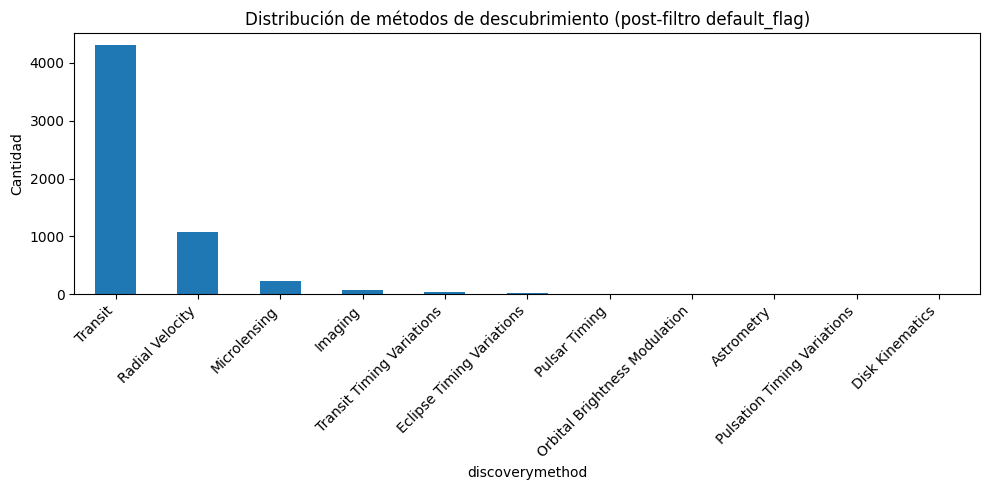

In [15]:
print('Distribución original de discoverymethod:')
print(df['discoverymethod'].value_counts())

plt.figure(figsize=(10, 5))
df['discoverymethod'].value_counts().plot(kind='bar')
plt.title('Distribución de métodos de descubrimiento (post-filtro default_flag)')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Clases agrupadas como Other: ['Imaging', 'Transit Timing Variations', 'Eclipse Timing Variations', 'Pulsar Timing', 'Orbital Brightness Modulation', 'Astrometry', 'Pulsation Timing Variations', 'Disk Kinematics']

Distribución final:
discoverymethod
Transit            4304
Radial Velocity    1080
Microlensing        230
Other               143
Name: count, dtype: int64


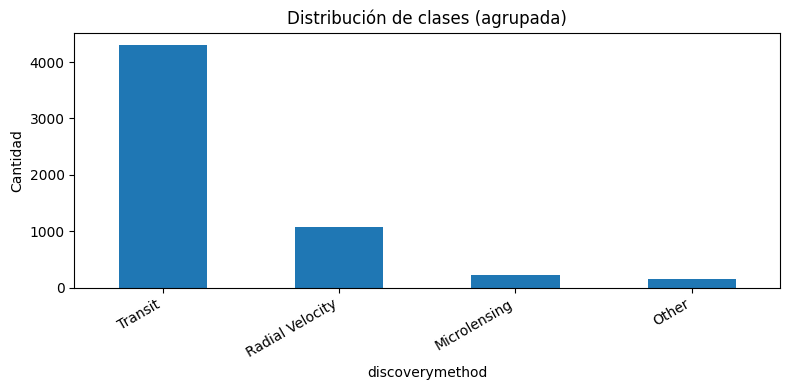

In [16]:
# Agrupar métodos con menos de 100 registros en 'Other'
MIN_CLASS_SIZE = 100
counts = df['discoverymethod'].value_counts()
minor_classes = counts[counts < MIN_CLASS_SIZE].index.tolist()
print(f'Clases agrupadas como Other: {minor_classes}')

df['discoverymethod'] = df['discoverymethod'].apply(
    lambda x: 'Other' if x in minor_classes else x
)

print('\nDistribución final:')
print(df['discoverymethod'].value_counts())

plt.figure(figsize=(8, 4))
df['discoverymethod'].value_counts().plot(kind='bar')
plt.title('Distribución de clases (agrupada)')
plt.ylabel('Cantidad')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Verificación final y exportación

In [17]:
print(f'Shape final: {df.shape}')
print(f'Nulos totales: {df.isnull().sum().sum()}')
print(f'\nTipos de datos:')
print(df.dtypes)
df.head()

Shape final: (5757, 22)
Nulos totales: 0

Tipos de datos:
sy_snum                  int64
sy_pnum                  int64
discoverymethod            str
disc_year                int64
pl_orbper              float64
pl_orbsmax             float64
pl_rade                float64
pl_bmasse              float64
pl_orbeccen            float64
st_teff                float64
st_rad                 float64
st_mass                float64
st_met                 float64
st_logg                float64
ra                     float64
dec                    float64
sy_dist                float64
sy_vmag                float64
sy_kmag                float64
sy_gaiamag             float64
pl_orbeccen_missing      int64
pl_bmasse_missing        int64
dtype: object


,sy_snum,sy_pnum,discoverymethod,disc_year,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,st_teff,st_rad,st_mass,st_met,st_logg,ra,dec,sy_dist,sy_vmag,sy_kmag,sy_gaiamag,pl_orbeccen_missing,pl_bmasse_missing
0,2,1,Radial Velocity,2007,323.2100,1.1780,2.4000,4914.8985,0.2380,4874.0000,13.7600,2.0900,-0.2600,2.4500,185.1788,17.7933,93.1846,4.7231,2.2820,4.4404,0,0
1,1,1,Radial Velocity,2009,516.2200,1.5300,2.4000,4684.8142,0.0800,4213.0000,29.7900,2.7800,-0.0200,1.9300,229.2746,71.8239,125.3210,5.0130,1.9390,4.5622,0,0
2,1,1,Radial Velocity,2008,186.7600,0.7750,2.4000,1131.1513,0.0000,4888.0000,11.5500,1.7800,-0.2100,2.5500,352.8241,39.2358,75.4392,5.2313,2.3310,4.9178,0,0
3,1,2,Radial Velocity,2002,1765.0389,2.7740,2.4000,2559.4722,0.3730,5551.0000,0.9500,0.9100,0.0200,4.4600,242.6021,43.8164,17.9323,6.6193,4.7140,6.3830,0,0
4,3,1,Radial Velocity,1996,798.5000,1.6600,2.4000,565.7374,0.6800,5750.0000,1.1300,1.0800,0.0600,4.3600,295.4656,50.5168,21.1397,6.2150,4.6510,6.0643,0,0


In [18]:
# Estadísticas descriptivas del dataset limpio
df.describe()

,sy_snum,sy_pnum,disc_year,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,st_teff,st_rad,st_mass,st_met,st_logg,ra,dec,sy_dist,sy_vmag,sy_kmag,sy_gaiamag,pl_orbeccen_missing,pl_bmasse_missing
count,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000,5757.0000
mean,1.1023,1.7603,2016.4680,4444.6835,13.8416,3.8272,408.8639,0.0884,5401.4729,1.4294,0.9499,0.0148,4.3899,235.2655,19.3228,694.5900,12.6525,10.5178,12.3750,0.5911,0.5300
std,0.3409,1.1454,4.6712,163961.8228,336.6838,4.0844,1058.7477,0.1343,1247.2731,3.5940,0.4149,0.1537,0.4022,90.7726,36.2376,1126.5093,3.0125,2.9428,2.9001,0.4917,0.4991
min,1.0000,1.0000,1992.0000,0.0907,0.0044,0.3100,0.0200,0.0000,415.0000,0.0100,0.0100,-1.0000,0.5400,0.1856,-88.1211,1.3012,0.8720,-3.0440,2.3643,0.0000,0.0000
25%,1.0000,1.0000,2014.0000,4.6027,0.0850,1.8600,88.8784,0.0300,5027.0000,0.8000,0.8000,-0.0300,4.3400,179.7059,-9.0229,109.8600,10.9710,8.7330,10.7180,0.0000,0.0000
50%,1.0000,1.0000,2016.0000,11.2670,0.1159,2.4000,88.8784,0.0300,5551.0000,0.9500,0.9500,0.0200,4.4600,285.5548,39.7227,399.0255,13.4165,11.3250,13.1671,1.0000,1.0000
75%,1.0000,2.0000,2020.0000,35.8007,0.1685,3.0100,152.5500,0.0960,5854.0000,1.1800,1.0700,0.0600,4.5500,293.3722,45.5511,839.9030,14.9340,12.7500,14.6770,1.0000,1.0000
max,4.0000,8.0000,2024.0000,8040000.0000,19000.0000,33.6000,9534.9000,0.9500,40000.0000,88.4700,10.9400,0.5600,7.9200,359.9750,86.8603,8240.0000,44.6100,33.1100,20.1861,1.0000,1.0000


In [19]:
import os
os.makedirs('../Data', exist_ok=True)
df.to_csv('../Data/NASA_Exoplanet_Clean.csv', index=False)
print('Dataset guardado en ../Data/NASA_Exoplanet_Clean.csv')

Dataset guardado en ../Data/NASA_Exoplanet_Clean.csv


In [ ]:
# revisar si esos planetas realmente tenian pl_rade nulo.
df_raw[df_raw['default_flag'] == 1][['pl_name', 'pl_rade']].head(10)

,pl_name,pl_rade
2,11 Com b,NaN
3,11 UMi b,NaN
6,14 And b,NaN
11,14 Her b,NaN
22,16 Cyg B b,NaN
23,17 Sco b,NaN
25,18 Del b,NaN
28,1RXS J160929.1-210524 b,NaN
32,24 Boo b,NaN
33,24 Sex b,NaN
